In [18]:
# Importa as bibliotecas necessárias para a análise exploratória
import pandas as pd        # manipulação e análise de dados
import numpy as np         # operações numéricas
import matplotlib.pyplot as plt  # criação de gráficos
import seaborn as sns      # visualizações estatísticas

In [19]:
# Carrega o CSV extraído do banco de dados para um DataFrame
df = pd.read_csv('/home/jander/churn_telco/data/processed/telco_churn.csv')

# Mostra as dimensões do DataFrame: (linhas, colunas)
print(df.shape)

# Mostra as primeiras 5 linhas para confirmar que os dados carregaram corretamente
df.head()

(7043, 21)


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   str    
 4   dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   str    
 7   multiplelines     7043 non-null   str    
 8   internetservice   7043 non-null   str    
 9   onlinesecurity    7043 non-null   str    
 10  onlinebackup      7043 non-null   str    
 11  deviceprotection  7043 non-null   str    
 12  techsupport       7043 non-null   str    
 13  streamingtv       7043 non-null   str    
 14  streamingmovies   7043 non-null   str    
 15  contract          7043 non-null   str    
 16  paperlessbilling  7043 non-null   str    
 17  paymen

In [21]:
# Verifica quantos valores únicos existem em totalcharges
# e mostra os primeiros para entender o problema
print(df['totalcharges'].nunique())

6531


In [22]:
# Tenta converter totalcharges para numérico sem tratar os espaços
# errors='raise' vai lançar erro ao encontrar valor inválido
df['totalcharges'].astype(float)

ValueError: could not convert string to float: ' '

In [ ]:
# pd.to_numeric com errors='coerce' converte o que conseguir
# e transforma o que não conseguir em NaN em vez de lançar erro
df['totalcharges_teste'] = pd.to_numeric(df['totalcharges'], errors='coerce')

# Mostra quantos NaN foram gerados — cada NaN era um espaço em branco
print(f"NaN gerados: {df['totalcharges_teste'].isna().sum()}")

NaN gerados: 11


In [ ]:
# Mostra os 11 clientes onde totalcharges era espaço em branco
# isna() retorna True para os NaN que foram gerados pela conversão
df[df['totalcharges_teste'].isna()][['customerid', 'tenure', 'monthlycharges', 'totalcharges']]

,customerid,tenure,monthlycharges,totalcharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1083,4367-NUYAO,0,25.75,
1344,1371-DWPAZ,0,56.05,
3333,7644-OMVMY,0,19.85,
3828,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [ ]:
#eu filtrei para ternure =1 e vi que a coluna mes e total são iguais. ou seja, ao completar um mês, o total é igual ao mensal. 
# antes de completar o mês, eu entendo que esse valor deve ser maior ou igual ao mensal. não faz sentido o total ser menor que  o mensal. portanto, preenchiria com o mesmo valor do mensal

In [ ]:
# Remove a coluna original que tinha espaços em branco
df = df.drop(columns=['totalcharges'])

# Renomeia a coluna de teste para o nome correto
df = df.rename(columns={'totalcharges_teste': 'totalcharges'})

# Confirma que não há NaN — mas os 11 clientes com tenure=0 viraram NaN!
print(f"NaN em totalcharges: {df['totalcharges'].isna().sum()}")

# Confirma o tipo numérico
print(f"Tipo: {df['totalcharges'].dtype}")

NaN em totalcharges: 11
Tipo: float64


In [ ]:
# Preenche os NaN de totalcharges com o valor de monthlycharges
# pois clientes com tenure=0 ainda não completaram o primeiro mês
df.loc[df['totalcharges'].isna(), 'totalcharges'] = df.loc[df['totalcharges'].isna(), 'monthlycharges']

# Confirma que não há mais NaN
print(f"NaN restantes: {df['totalcharges'].isna().sum()}")

NaN restantes: 0


In [ ]:
# Conta os valores nulos por coluna em todo o DataFrame
df.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
churn               0
totalcharges        0
dtype: int64

In [ ]:
# Conta a distribuição da variável alvo
print(df['churn'].value_counts())

# Mostra em percentual
print(df['churn'].value_counts(normalize=True).round(2) * 100)

churn
No     5174
Yes    1869
Name: count, dtype: int64
churn
No     73.0
Yes    27.0
Name: proportion, dtype: float64


In [ ]:
# O dataset é desbalanceado:
# 73% não cancelaram  (classe majoritária) 27% cancelaram      (classe minoritária)


In [ ]:
df.describe()

,seniorcitizen,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.798992
std,0.368612,24.559481,30.090047,2266.730170
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
df.describe(include=object)

/tmp/ipykernel_4953/3998025828.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=object)


,customerid,gender,partner,dependents,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [ ]:
# Confirma os valores únicos das colunas de serviços adicionais
df['multiplelines'].unique()

<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

In [ ]:
# Verifica os valores únicos das colunas de serviços de internet
df['onlinesecurity'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

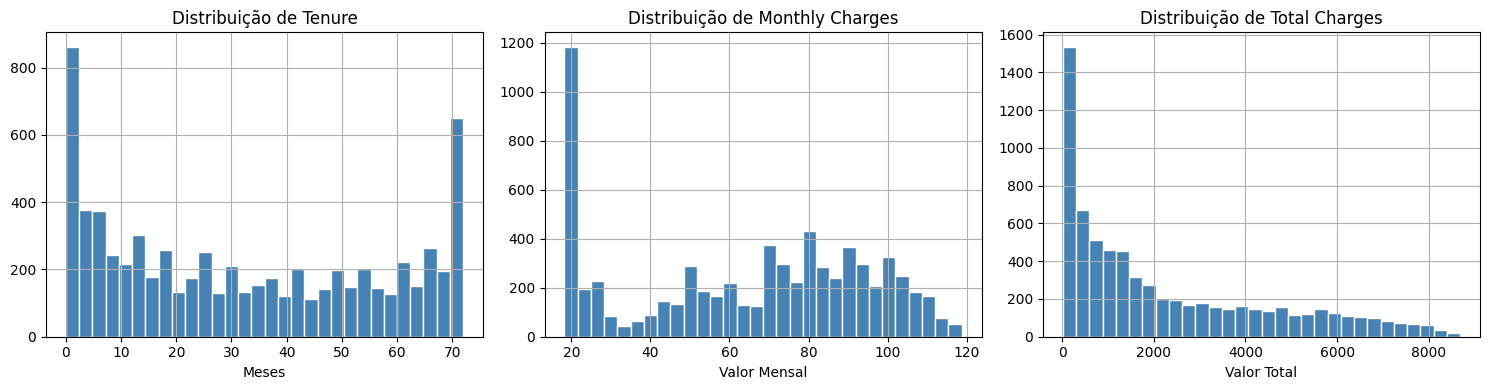

In [ ]:
# Cria histogramas para as variáveis numéricas para ver a distribuição
fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # 1 linha, 3 gráficos lado a lado

# Histograma de tenure
df['tenure'].hist(ax=axes[0], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição de Tenure')  # título do gráfico
axes[0].set_xlabel('Meses')                  # rótulo do eixo x

# Histograma de monthlycharges
df['monthlycharges'].hist(ax=axes[1], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Distribuição de Monthly Charges')
axes[1].set_xlabel('Valor Mensal')

# Histograma de totalcharges
df['totalcharges'].hist(ax=axes[2], bins=30, color='steelblue', edgecolor='white')
axes[2].set_title('Distribuição de Total Charges')
axes[2].set_xlabel('Valor Total')

plt.tight_layout()  # ajusta o espaçamento entre os gráficos
plt.show()          # exibe os gráficos

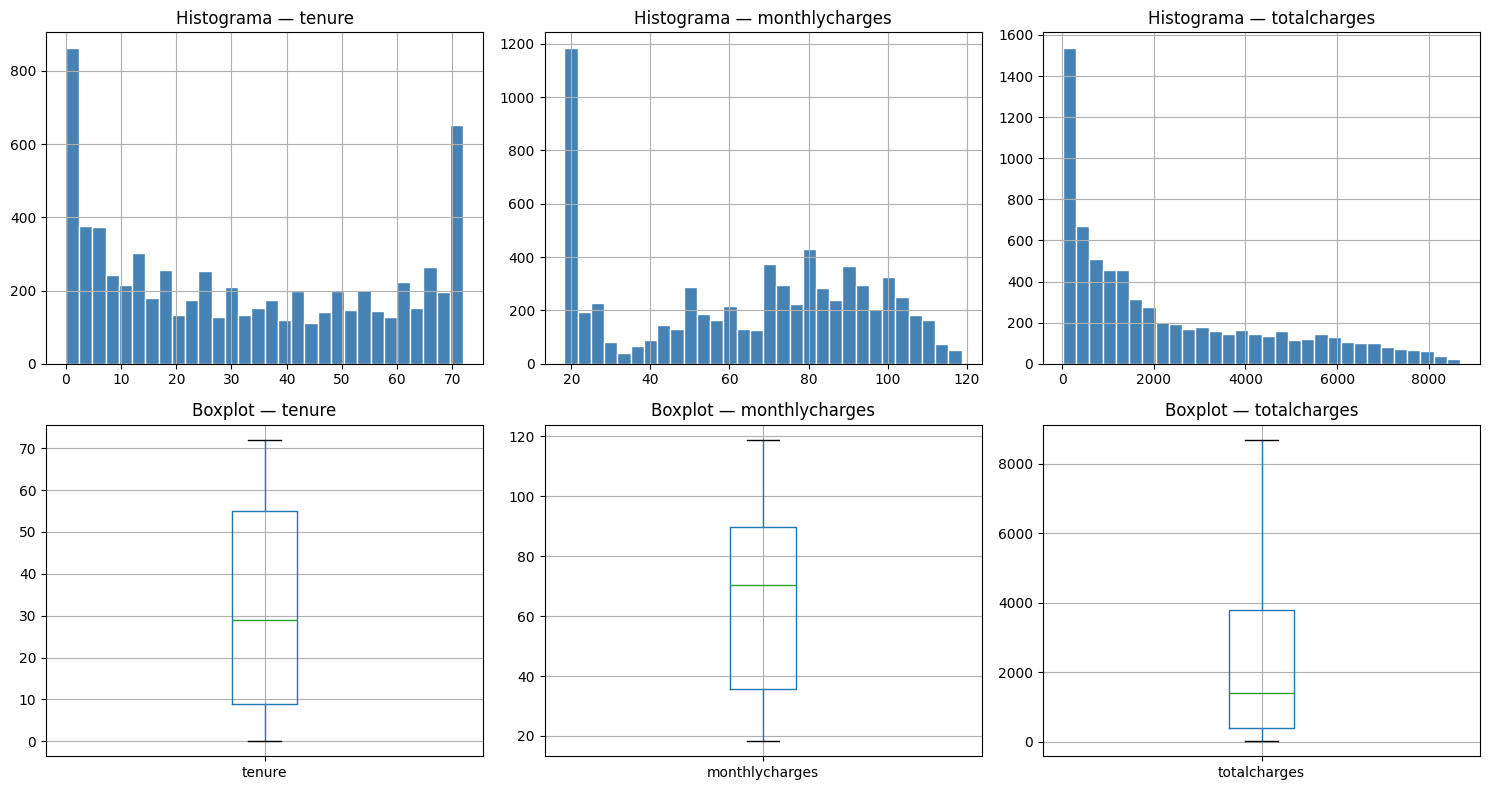

In [ ]:
# Cria histograma e boxplot lado a lado para cada variável numérica
fig, axes = plt.subplots(2, 3, figsize=(15, 8))  # 2 linhas, 3 colunas

colunas = ['tenure', 'monthlycharges', 'totalcharges']  # colunas a analisar

for i, coluna in enumerate(colunas):  # percorre cada coluna
    # linha 0 — histogramas
    df[coluna].hist(ax=axes[0][i], bins=30, color='steelblue', edgecolor='white')
    axes[0][i].set_title(f'Histograma — {coluna}')  # título com nome da coluna

    # linha 1 — boxplots
    df.boxplot(column=coluna, ax=axes[1][i])
    axes[1][i].set_title(f'Boxplot — {coluna}')  # título com nome da coluna

plt.tight_layout()  # ajusta espaçamento entre os gráficos
plt.show()          # exibe todos os gráficos

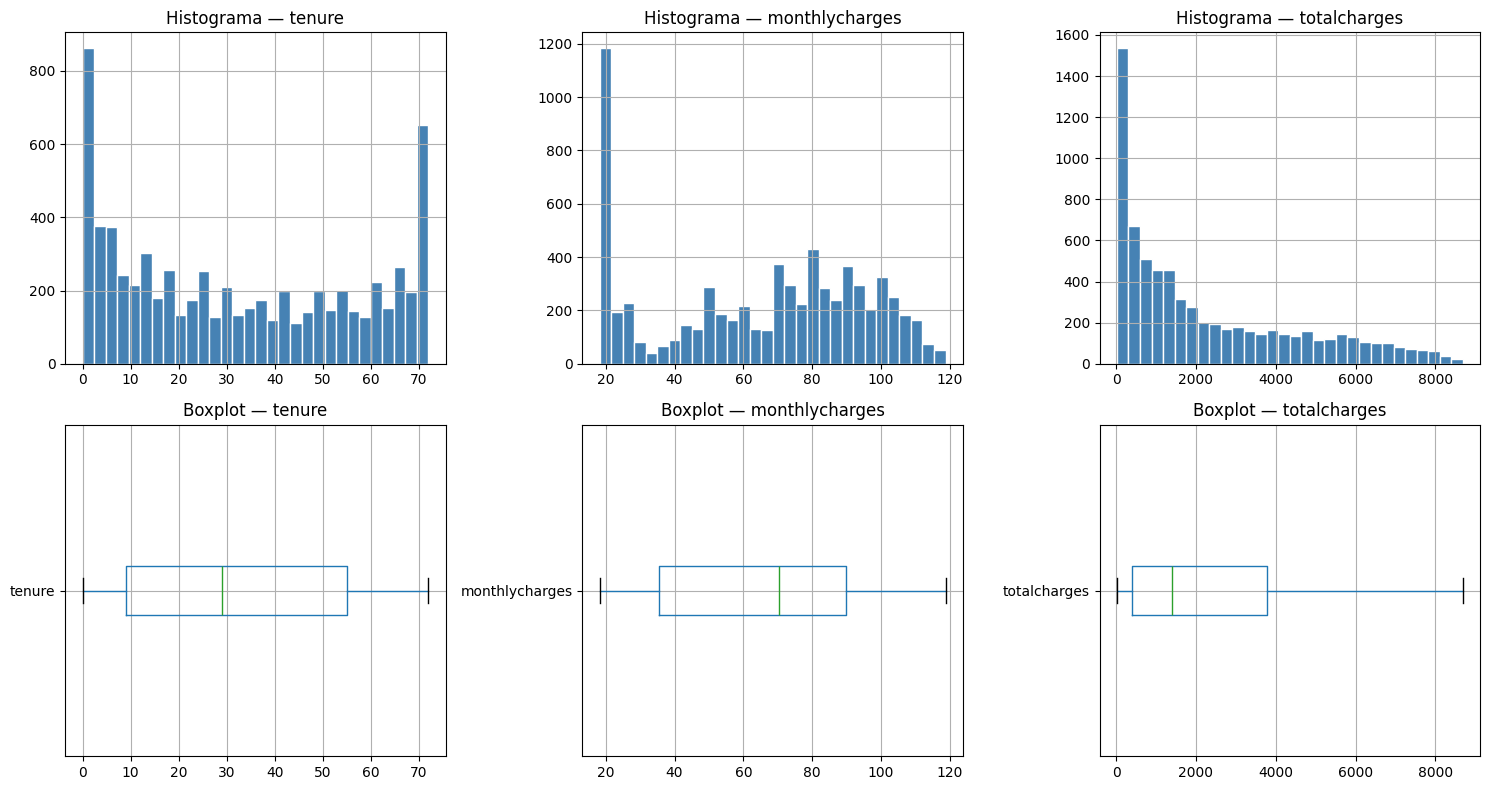

In [ ]:
# Cria histograma e boxplot horizontal lado a lado para cada variável numérica
fig, axes = plt.subplots(2, 3, figsize=(15, 8))  # 2 linhas, 3 colunas

colunas = ['tenure', 'monthlycharges', 'totalcharges']  # colunas a analisar

for i, coluna in enumerate(colunas):  # percorre cada coluna
    # linha 0 — histogramas
    df[coluna].hist(ax=axes[0][i], bins=30, color='steelblue', edgecolor='white')
    axes[0][i].set_title(f'Histograma — {coluna}')

    # linha 1 — boxplots horizontais (vert=False)
    df.boxplot(column=coluna, ax=axes[1][i], vert=False)  # vert=False deixa horizontal
    axes[1][i].set_title(f'Boxplot — {coluna}')

plt.tight_layout()  # ajusta espaçamento entre os gráficos
plt.show()          # exibe todos os gráficos

In [ ]:
# Taxa de churn por tipo de contrato — cruzamento direto com a variável alvo
df.groupby('contract')['churn'].value_counts(normalize=True).unstack().round(2) * 100

churn,No,Yes
contract,,
Month-to-month,57.0,43.0
One year,89.0,11.0
Two year,97.0,3.0


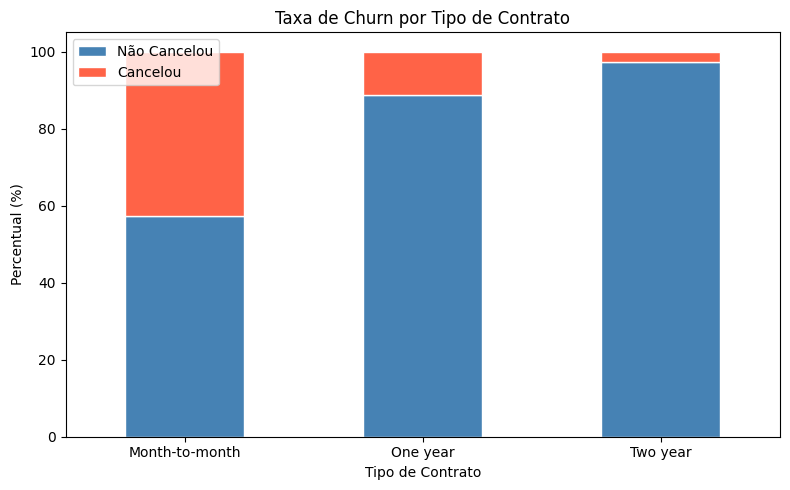

In [ ]:
# Calcula a taxa de churn por tipo de contrato em percentual
churn_contrato = df.groupby('contract')['churn'].value_counts(normalize=True).unstack() * 100

# Cria gráfico de barras empilhadas para visualizar a proporção
churn_contrato.plot(kind='bar', stacked=True, figsize=(8, 5),
                    color=['steelblue', 'tomato'],  # azul para No, vermelho para Yes
                    edgecolor='white')

plt.title('Taxa de Churn por Tipo de Contrato')  # título do gráfico
plt.xlabel('Tipo de Contrato')                    # rótulo eixo x
plt.ylabel('Percentual (%)')                      # rótulo eixo y
plt.xticks(rotation=0)                            # mantém rótulos na horizontal
plt.legend(['Não Cancelou', 'Cancelou'])          # legenda clara
plt.tight_layout()                                # ajusta espaçamento
plt.show()                                        # exibe o gráfico

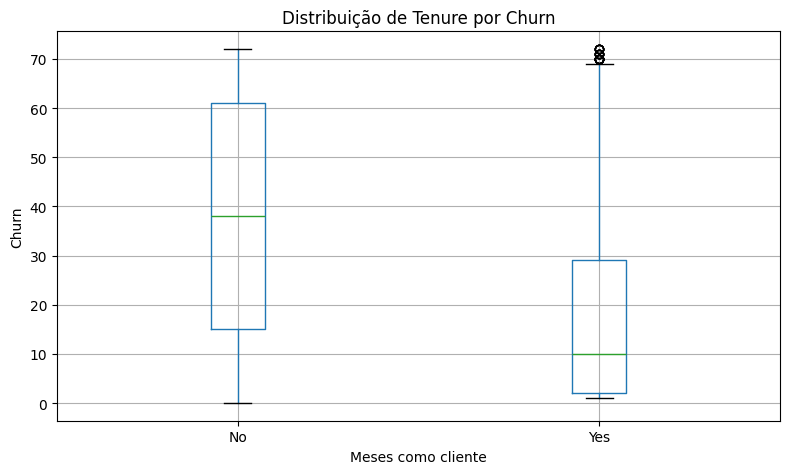

In [ ]:
# Cria boxplot de tenure separado por churn
# para ver se clientes que cancelaram têm menos tempo de casa
df.boxplot(column='tenure', by='churn', figsize=(8, 5), vert=True)

plt.title('Distribuição de Tenure por Churn')  # título do gráfico
plt.suptitle('')                                # remove o título automático do pandas
plt.xlabel('Meses como cliente')               # rótulo eixo x
plt.ylabel('Churn')                            # rótulo eixo y
plt.tight_layout()
plt.show()

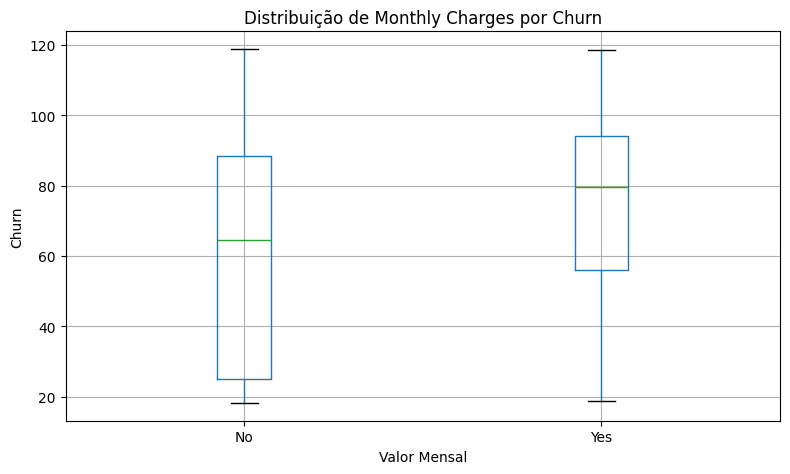

In [ ]:
# Boxplot de monthlycharges separado por churn
df.boxplot(column='monthlycharges', by='churn', figsize=(8, 5), vert=True)

plt.title('Distribuição de Monthly Charges por Churn') 
plt.suptitle('')                                        
plt.xlabel('Valor Mensal')                             
plt.ylabel('Churn')                                    
plt.tight_layout()
plt.show()

In [ ]:
# Taxa de churn por tipo de serviço de internet
df.groupby('internetservice')['churn'].value_counts(normalize=True).unstack().round(2) * 100

churn,No,Yes
internetservice,,
DSL,81.0,19.0
Fiber optic,58.0,42.0
No,93.0,7.0


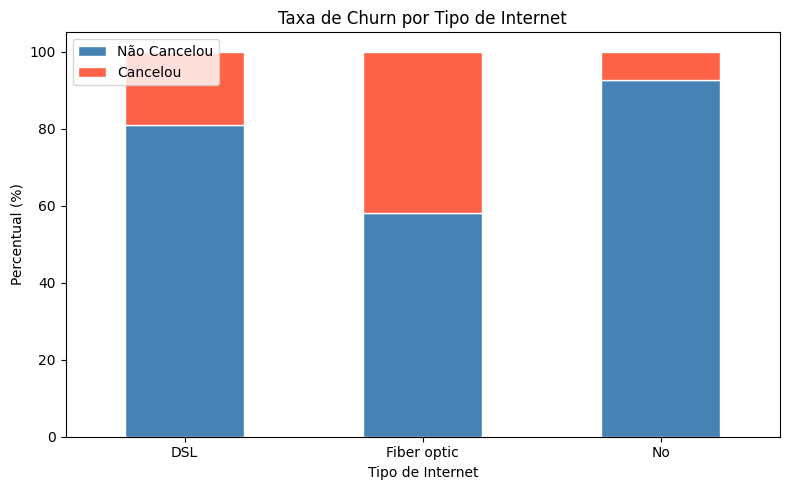

In [ ]:
# Taxa de churn por tipo de internet em gráfico de barras
churn_internet = df.groupby('internetservice')['churn'].value_counts(normalize=True).unstack() * 100

churn_internet.plot(kind='bar', stacked=True, figsize=(8, 5),
                    color=['steelblue', 'tomato'],
                    edgecolor='white')

plt.title('Taxa de Churn por Tipo de Internet')
plt.xlabel('Tipo de Internet')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)
plt.legend(['Não Cancelou', 'Cancelou'])
plt.tight_layout()
plt.show()

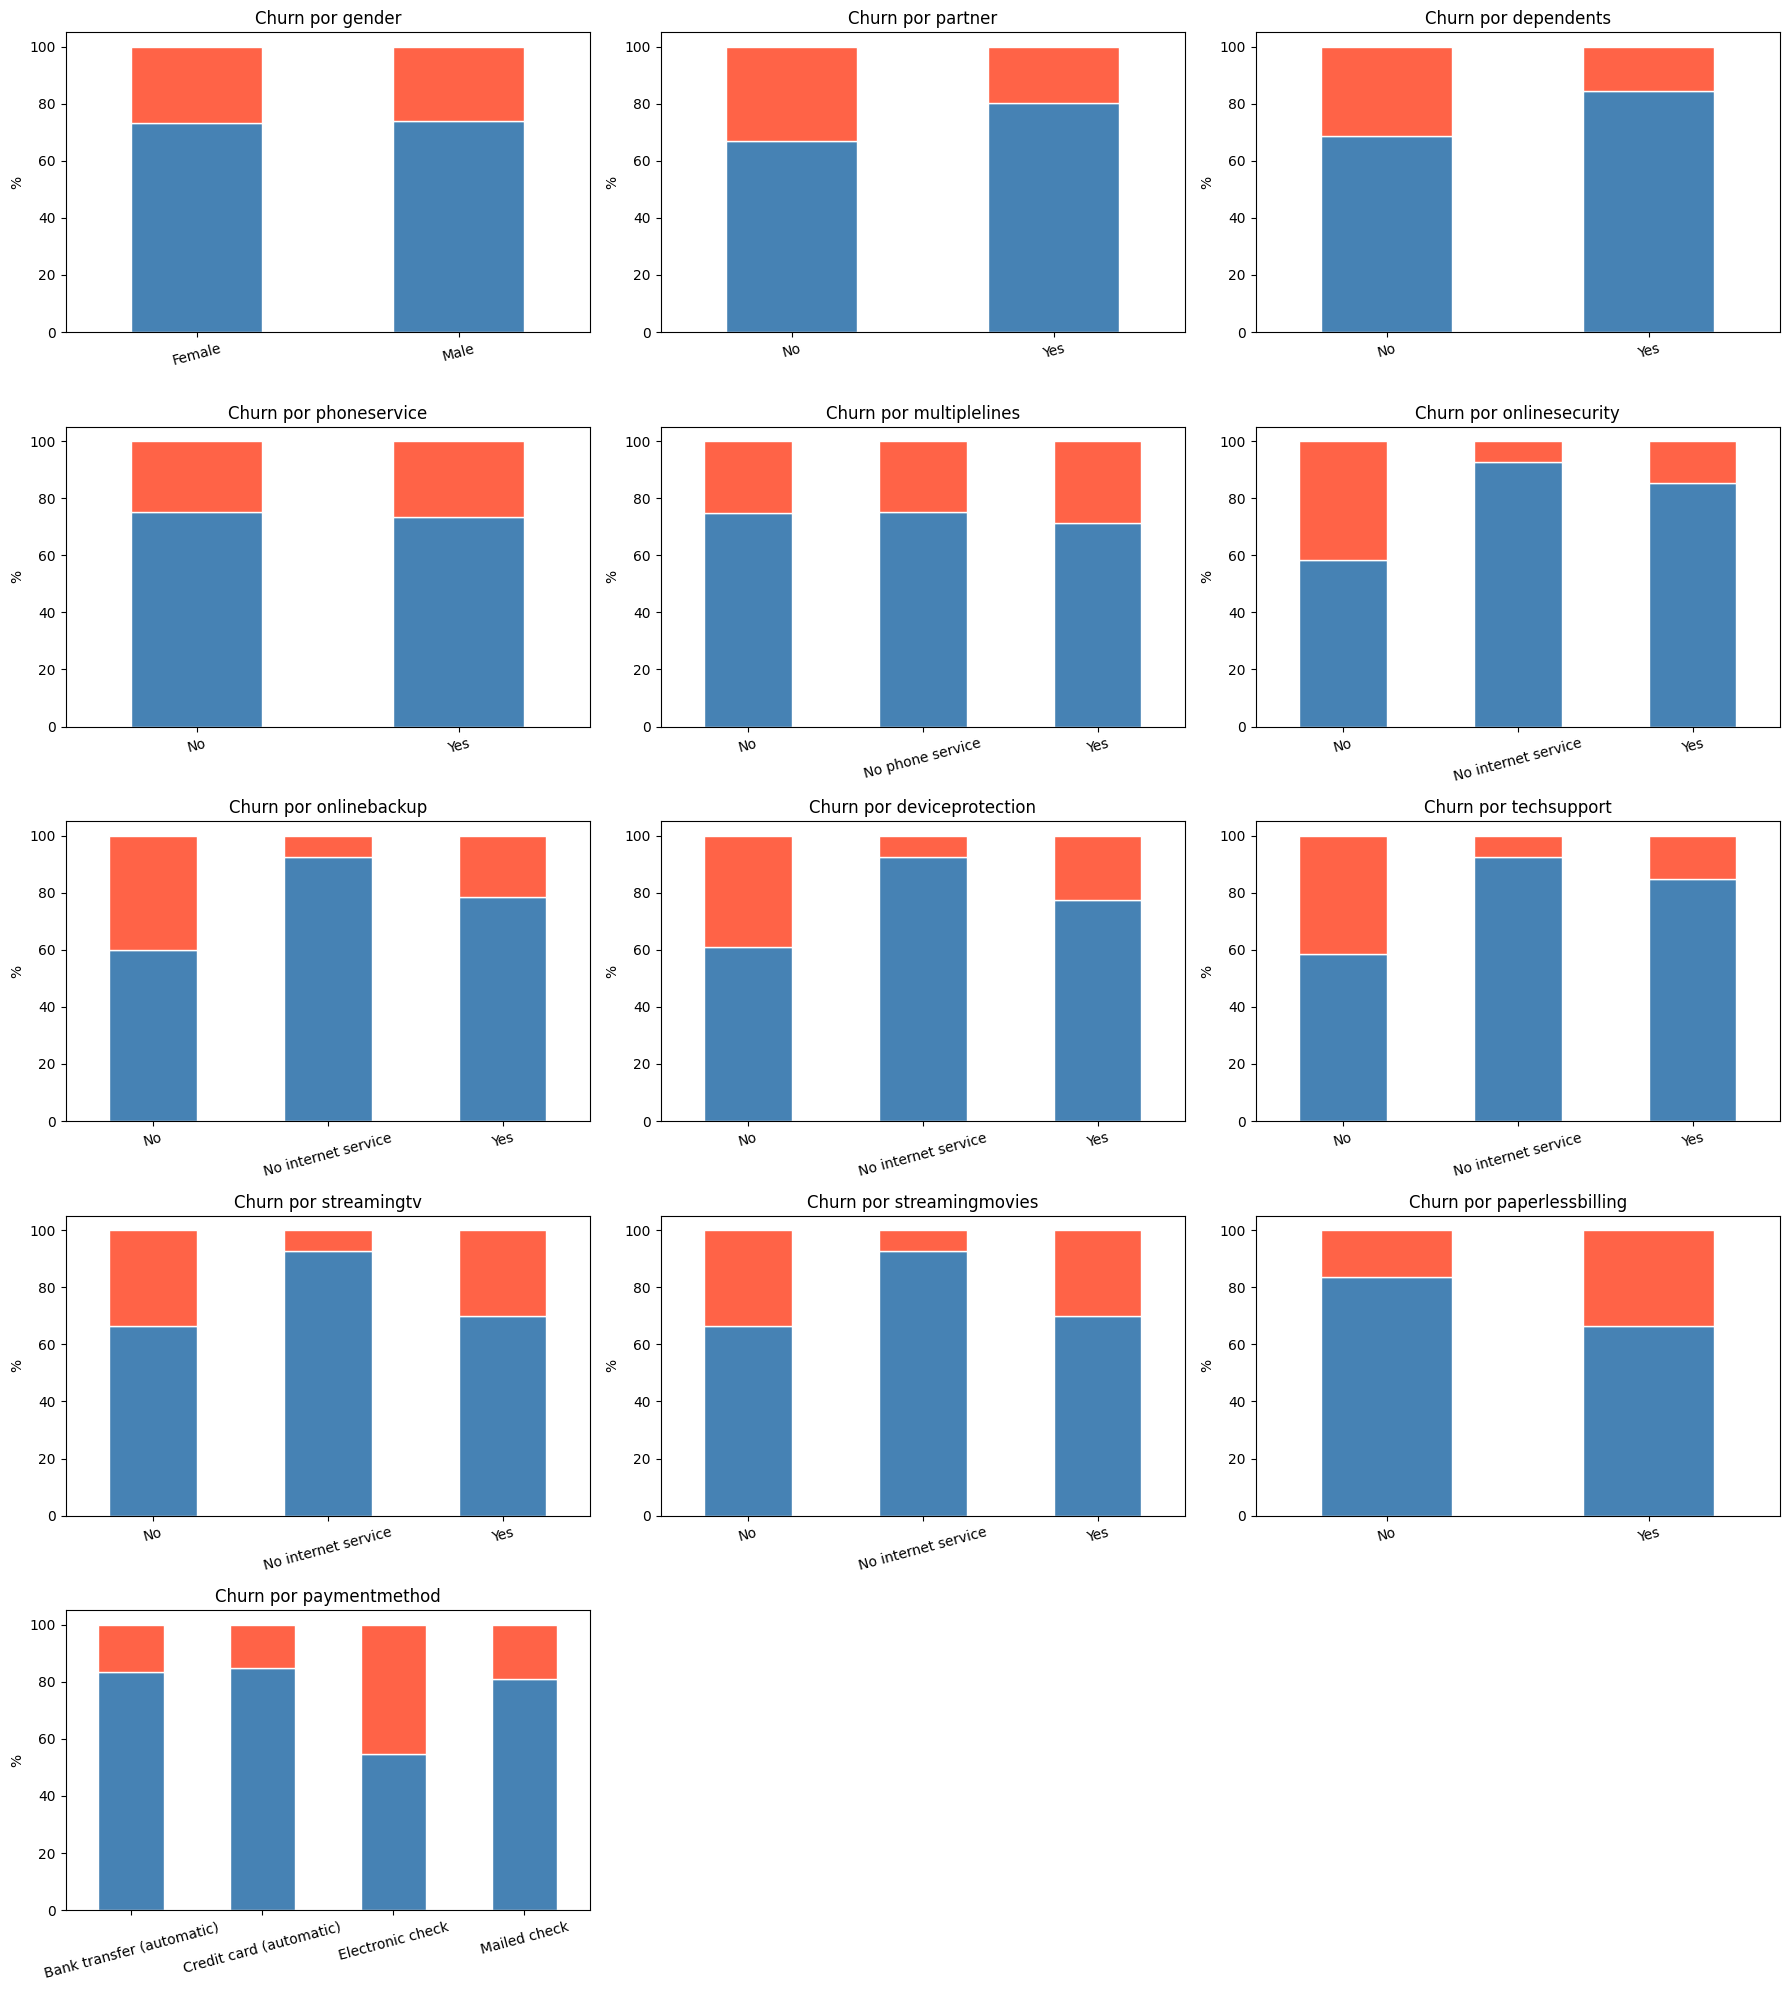

In [ ]:
# Lista todas as colunas categóricas relevantes para analisar
categoricas = ['gender', 'partner', 'dependents', 'phoneservice',
               'multiplelines', 'onlinesecurity', 'onlinebackup',
               'deviceprotection', 'techsupport', 'streamingtv',
               'streamingmovies', 'paperlessbilling', 'paymentmethod']

# Cria um gráfico de barras de churn para cada variável categórica
fig, axes = plt.subplots(5, 3, figsize=(18, 20))  # 5 linhas, 3 colunas
axes = axes.flatten()  # transforma a grade em lista para facilitar o loop

for i, coluna in enumerate(categoricas):  # percorre cada coluna
    # calcula taxa de churn por categoria
    churn_cat = df.groupby(coluna)['churn'].value_counts(normalize=True).unstack() * 100
    
    # plota barras empilhadas
    churn_cat.plot(kind='bar', stacked=True, ax=axes[i],
                   color=['steelblue', 'tomato'], edgecolor='white', legend=False)
    
    axes[i].set_title(f'Churn por {coluna}')  # título com nome da coluna
    axes[i].set_xlabel('')                     # remove rótulo do eixo x
    axes[i].set_ylabel('%')                    # rótulo do eixo y
    axes[i].tick_params(axis='x', rotation=15) # inclina os rótulos para não sobrepor

# Remove os subgráficos vazios (criamos 15 espaços mas temos 13 colunas)
for j in range(len(categoricas), len(axes)):  # percorre os espaços sobrando
    fig.delaxes(axes[j])                      # remove o eixo vazio

plt.tight_layout()
plt.show()

In [27]:
# Converte churn para binário — Yes=1 (cancelou), No=0 (não cancelou)
df['churn_bin'] = (df['churn'] == 'Yes').astype(int)

# Confirma que a coluna foi criada
print(df['churn_bin'].value_counts())

churn_bin
0    5174
1    1869
Name: count, dtype: int64


In [28]:
from optbinning import BinningProcess  # importa o processo de binning e cálculo de IV

# Define as variáveis para calcular o IV
# exclui customerid (é só identificador) e churn_bin (é o alvo)
variaveis = ['tenure', 'monthlycharges', 'totalcharges', 'seniorcitizen',
             'gender', 'partner', 'dependents', 'phoneservice',
             'multiplelines', 'internetservice', 'onlinesecurity',
             'onlinebackup', 'deviceprotection', 'techsupport',
             'streamingtv', 'streamingmovies', 'contract',
             'paperlessbilling', 'paymentmethod']

# Define quais variáveis são categóricas para o optbinning tratar corretamente
categoricas = ['gender', 'partner', 'dependents', 'phoneservice',
               'multiplelines', 'internetservice', 'onlinesecurity',
               'onlinebackup', 'deviceprotection', 'techsupport',
               'streamingtv', 'streamingmovies', 'contract',
               'paperlessbilling', 'paymentmethod']

# Cria o processo de binning
# special_codes=[] evita erros com valores especiais
binning_process = BinningProcess(
    variable_names=variaveis,           # lista de variáveis a analisar
    categorical_variables=categoricas   # indica quais são categóricas
)

# Ajusta o processo aos dados e calcula o IV
binning_process.fit(df[variaveis], df['churn_bin'])

# Extrai o sumário com IV de cada variável
sumario = binning_process.summary()

# Ordena pelo IV de forma decrescente — maior IV = mais preditiva
sumario_ordenado = sumario[['name', 'iv']].sort_values('iv', ascending=False).round(3)

print("=== INFORMATION VALUE — RANKING DE VARIÁVEIS ===")
print(sumario_ordenado.to_string(index=False))

TypeError: check_array() got an unexpected keyword argument 'force_all_finite'. Did you mean 'ensure_all_finite'?

In [29]:
import scorecardpy as sc  # importa a biblioteca de scorecard

# Cria uma cópia do DataFrame com churn como 0/1
# o scorecardpy espera a variável alvo como inteiro
df_sc = df.drop(columns=['customerid', 'churn'])  # remove ID e churn original

# Calcula o IV para todas as variáveis
iv = sc.iv(df_sc, y='churn_bin')

# Ordena pelo IV de forma decrescente — maior IV = mais preditiva
iv_ordenado = iv.sort_values('info_value', ascending=False).round(3)

print("=== INFORMATION VALUE — RANKING DE VARIÁVEIS ===")
print(iv_ordenado[['variable', 'info_value']].to_string(index=False))

ModuleNotFoundError: No module named 'pkg_resources'

In [30]:
import numpy as np

def calcular_iv(df, variavel, alvo):
    """
    Calcula o Information Value de uma variável em relação ao alvo binário.
    Funciona para variáveis categóricas e numéricas (via binning automático).
    """
    # Se numérica, divide em 10 faixas iguais para criar categorias
    if df[variavel].dtype in ['int64', 'float64'] and df[variavel].nunique() > 10:
        df = df.copy()
        df[variavel] = pd.cut(df[variavel], bins=10, duplicates='drop')

    # Conta eventos (churn=1) e não-eventos (churn=0) por categoria
    tabela = df.groupby(variavel)[alvo].agg(['sum', 'count'])
    tabela.columns = ['eventos', 'total']               # renomeia as colunas
    tabela['nao_eventos'] = tabela['total'] - tabela['eventos']  # calcula não-eventos

    # Calcula a distribuição percentual de eventos e não-eventos
    tabela['pct_eventos']     = tabela['eventos']     / tabela['eventos'].sum()
    tabela['pct_nao_eventos'] = tabela['nao_eventos'] / tabela['nao_eventos'].sum()

    # Evita divisão por zero substituindo 0 por um valor muito pequeno
    tabela['pct_eventos']     = tabela['pct_eventos'].replace(0, 0.0001)
    tabela['pct_nao_eventos'] = tabela['pct_nao_eventos'].replace(0, 0.0001)

    # Calcula o WOE e IV para cada faixa
    tabela['woe'] = np.log(tabela['pct_eventos'] / tabela['pct_nao_eventos'])
    tabela['iv']  = (tabela['pct_eventos'] - tabela['pct_nao_eventos']) * tabela['woe']

    return tabela['iv'].sum()  # IV final é a soma de todas as faixas

# Calcula o IV para todas as variáveis
variaveis = ['tenure', 'monthlycharges', 'totalcharges', 'seniorcitizen',
             'gender', 'partner', 'dependents', 'phoneservice',
             'multiplelines', 'internetservice', 'onlinesecurity',
             'onlinebackup', 'deviceprotection', 'techsupport',
             'streamingtv', 'streamingmovies', 'contract',
             'paperlessbilling', 'paymentmethod']

resultados = []  # lista para guardar os resultados

for variavel in variaveis:
    iv_valor = calcular_iv(df, variavel, 'churn_bin')  # calcula IV de cada variável
    resultados.append({'variavel': variavel, 'iv': round(iv_valor, 3)})

# Transforma em DataFrame e ordena pelo IV decrescente
iv_df = pd.DataFrame(resultados).sort_values('iv', ascending=False)

print("=== INFORMATION VALUE — RANKING DE VARIÁVEIS ===")
print(iv_df.to_string(index=False))

=== INFORMATION VALUE — RANKING DE VARIÁVEIS ===
        variavel    iv
    totalcharges 1.727
        contract 1.239
          tenure 0.761
  onlinesecurity 0.718
     techsupport 0.700
 internetservice 0.618
    onlinebackup 0.529
deviceprotection 0.500
  monthlycharges 0.475
   paymentmethod 0.457
 streamingmovies 0.381
     streamingtv 0.380
paperlessbilling 0.203
      dependents 0.155
         partner 0.119
   seniorcitizen 0.106
   multiplelines 0.008
    phoneservice 0.001
          gender 0.000


In [31]:
# Salva o DataFrame limpo em data/processed para usar nas próximas etapas
df.to_csv('/home/jander/churn_telco/data/processed/telco_churn_limpo.csv', index=False)

# Confirma que o arquivo foi salvo
print("Arquivo salvo com sucesso!")
print(f"Shape: {df.shape}")

Arquivo salvo com sucesso!
Shape: (7043, 22)
